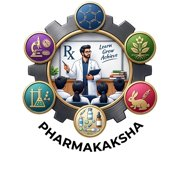

# BP301T · Unit V — Unsupervised Learning and Case Studies
**Pharmakaksha · Learn · Grow · Achieve**
*Introduction to Machine Learning in Pharmaceutical Sciences · B.Pharm Semester III · PCI NEP 2020*

This notebook contains every example and demo from the Unit V study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit5_Unsupervised_Learning.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit5_Unsupervised_Learning.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data (except scikit-learn's built-in breast-cancer dataset). The models are for learning machine learning only. They are not clinical tools.

## 5.1 What is unsupervised learning?
Unsupervised learning finds structure in data that has **no labels**. Clustering groups similar rows; dimensionality reduction (such as PCA) squeezes many columns into a few for plotting.

## 5.2 K-means clustering
K-means: (1) choose *k*; (2) place *k* centroids; (3) assign every point to its nearest centroid; (4) move each centroid to the mean of its points; (5) repeat until nothing changes. First, a tiny example with six patients:

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

toy = pd.DataFrame({"hba1c": [5.4, 5.8, 5.6, 9.1, 8.7, 9.5],
                    "bmi": [22, 24, 23, 33, 31, 34]})
km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(toy)
toy["cluster"] = km.labels_
print(toy)
print("Centroids:\n", pd.DataFrame(km.cluster_centers_, columns=["hba1c", "bmi"]).round(2))

## 5.3 Scaling and choosing k
`patient_profiles.csv` holds 240 fictional clinic patients and six measurements. The columns have very different units, so we **standardise** them first. Then we try k = 1 to 10 and look for the **elbow** in inertia (within-cluster sum of squares) and the highest **silhouette score**.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

pts = load("patient_profiles.csv")
cols = ["age", "bmi", "hba1c", "systolic_bp", "num_meds", "visits_per_year"]
print(pts[cols].describe().round(1))

Xs = StandardScaler().fit_transform(pts[cols])
ks = range(1, 11)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs).inertia_ for k in ks]
sil = {k: silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xs)) for k in range(2, 11)}
print("\nSilhouette scores:", {k: round(v, 3) for k, v in sil.items()})

In [ ]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(ks, inertia, marker="o", color="#12303A")
plt.axvline(4, color="#E07A2E", linestyle="--")
plt.xlabel("Number of clusters k"); plt.ylabel("Inertia"); plt.title("Elbow method")
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(list(sil.keys()), list(sil.values()), marker="s", color="#17725C")
plt.axvline(4, color="#E07A2E", linestyle="--")
plt.xlabel("Number of clusters k"); plt.ylabel("Silhouette score"); plt.title("Silhouette score")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5.4 Case study 1: patient segmentation

In [ ]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xs)
pts["segment"] = km4.labels_
profile = pts.groupby("segment")[cols].mean().round(1)
profile["patients"] = pts["segment"].value_counts().sort_index()
print(profile)

**Interpreting clusters** means reading each segment's averages and giving it a clinical name. The names below follow the printed averages.

In [ ]:
def name_segment(row):
    if row["hba1c"] < 6.0:
        return "Young and healthy"
    if row["hba1c"] >= 8.0:
        return "Uncontrolled diabetes"
    if row["num_meds"] >= 8:
        return "Frail, multimorbid"
    return "Older hypertensive"

profile["name"] = profile.apply(name_segment, axis=1)
pts["segment_name"] = pts["segment"].map(profile["name"])
print(profile[["name", "patients", "age", "hba1c", "systolic_bp", "num_meds"]])

In [ ]:
from sklearn.decomposition import PCA

xy = PCA(n_components=2).fit_transform(Xs)
colours = {"Young and healthy": "#17725C", "Uncontrolled diabetes": "#E07A2E",
           "Older hypertensive": "#12303A", "Frail, multimorbid": "#8E44AD"}
plt.figure(figsize=(8, 6))
for name, c in colours.items():
    m = pts["segment_name"] == name
    plt.scatter(xy[m, 0], xy[m, 1], color=c, s=30, alpha=0.8, label=name)
plt.xlabel("Principal component 1"); plt.ylabel("Principal component 2")
plt.title("Four patient segments (K-means, k = 4)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5.5 Case study 2: grouping drugs by properties
`drug_properties.csv` lists 30 well-known drugs. The descriptors were calculated from each structure with RDKit: molecular weight, calculated logP (lipophilicity), H-bond donors and acceptors, topological polar surface area (TPSA) and rotatable bonds.

In [ ]:
drugs = load("drug_properties.csv")
dcols = ["mol_weight", "clogp", "hbd", "hba", "tpsa", "rot_bonds"]
print(drugs.head())

Xd = StandardScaler().fit_transform(drugs[dcols])
print({k: round(silhouette_score(Xd, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xd)), 3) for k in range(2, 7)})

In [ ]:
kmd = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xd)
drugs["group"] = kmd.labels_
print(drugs.groupby("group")[dcols].mean().round(1))
for g, sub in drugs.groupby("group"):
    print(f"\nGroup {g}: {', '.join(sub['drug'])}")

In [ ]:
pca = PCA(n_components=2).fit(Xd)
pc = pca.transform(Xd)
print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_.round(2))

palette = ["#12303A", "#E07A2E", "#17725C"]
plt.figure(figsize=(10, 7))
for g in range(3):
    m = drugs["group"] == g
    plt.scatter(pc[m, 0], pc[m, 1], s=70, color=palette[g], label=f"Group {g}")
for (x, y_), name in zip(pc, drugs["drug"]):
    plt.annotate(name, (x, y_), fontsize=8, xytext=(4, 3), textcoords="offset points")
plt.xlabel("PC1 (size and polarity)"); plt.ylabel("PC2")
plt.title("30 drugs grouped by physicochemical properties")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Link to Lipinski's Rule of Five:** an oral drug usually has MW ≤ 500, logP ≤ 5, HBD ≤ 5 and HBA ≤ 10. Count the rule breaks for each drug:

In [ ]:
drugs["ro5_violations"] = ((drugs["mol_weight"] > 500).astype(int) + (drugs["clogp"] > 5).astype(int)
                           + (drugs["hbd"] > 5).astype(int) + (drugs["hba"] > 10).astype(int))
print(drugs.loc[drugs["ro5_violations"] > 0, ["drug", "mol_weight", "clogp", "ro5_violations"]])
print(drugs.groupby("group")["ro5_violations"].sum())

## Quick check
K-means gives you four clusters. Does that prove there are four real kinds of patient? Decide, then run the cell.

In [ ]:
print("No. K-means always returns k groups. Check the elbow, silhouette and whether the groups make clinical sense.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Run K-means on the patient data with k = 3. Which two segments merge?

**2.** Run K-means on the patient data **without** scaling (k = 4). Which column dominates, and why?

**3.** Which drug is closest to the centre of its group? (Hint: `kmd.transform(Xd)` gives distances to each centroid.)

**4.** Leave out `visits_per_year` and cluster on the other five patient columns. Do you still get four sensible segments?

---
## Solutions

In [ ]:
# 1
k3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(Xs)
print(pd.crosstab(pts["segment_name"], k3))

In [ ]:
# 2
raw = KMeans(n_clusters=4, n_init=10, random_state=42).fit(pts[cols])
print(pd.DataFrame(raw.cluster_centers_, columns=cols).round(1))
# systolic_bp and age have the largest numbers, so they dominate the distances.

In [ ]:
# 3
dist = kmd.transform(Xd).min(axis=1)
drugs["dist"] = dist
print(drugs.loc[drugs.groupby("group")["dist"].idxmin(), ["group", "drug"]])

In [ ]:
# 4
five = ["age", "bmi", "hba1c", "systolic_bp", "num_meds"]
k5 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(StandardScaler().fit_transform(pts[five]))
print(pd.crosstab(pts["segment_name"], k5))

---
**Next:** BP604T — AI Applications in Pharmaceutical Sciences (Semester VI). Pharmakaksha · Learn · Grow · Achieve